In [ ]:
##  missing values handling ---- 

# 1. remove the data column itself
# 2. Imputing/filling the data column univariate
# 3. Imputing/filling the data column multivariate

In [ ]:
### complete case analysis  --- removing the rows which have missing values or working on the 
### variables which dont have any missing values

###  CCA -- applied in case where the data is missing randomly (mostly 5%)  --- not in case where 50 rows are missing in a sequence

# -- this way the data distribution stays the same
## if > 5% dont apply CCA  --- Or if 900  values missing out of 1000 in a col -- remove the col

## we need to checkk the distribution of data does not affect much

# disadvantages --1. when too much data is missing CCA is not supporting
                #-2. the model does not work when it comes across the missing data on server

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
Data1 = pd.read_csv('missing_values_study.csv')
Data1.head(2)

,patient_id,age,sex,bmi,systolic_bp,cholesterol,glucose,exercise_hrs_week,smoker
0,1,34,F,24.1,118.0,185.0,92.0,3.5,No
1,2,45,M,28.7,132.0,210.0,101.0,1.0,Yes


In [9]:
Data1.isnull().mean()*100  ### percentage

patient_id            0.000000
age                   0.000000
sex                   0.000000
bmi                  16.666667
systolic_bp           6.666667
cholesterol          13.333333
glucose              10.000000
exercise_hrs_week     6.666667
smoker               10.000000
dtype: float64

In [10]:
Data1.shape

(30, 9)

In [12]:
cols = [var for var in Data1.columns if Data1[var].isnull().mean() <0.05 and Data1[var].isnull().mean() > 0]
cols

[]

In [14]:
Data2 = pd.read_csv('missing_values_study_100.csv')
Data2.head(2)

,patient_id,age,sex,bmi,systolic_bp,cholesterol,glucose,exercise_hrs_week,smoker
0,1,26,F,26.4,120.0,183.0,91.0,2.9,No
1,2,26,F,22.5,128.0,NaN,78.0,1.5,No


In [15]:
Data2.shape

(100, 9)

In [18]:
Data2.isnull().mean()*100

patient_id           0.0
age                  0.0
sex                  0.0
bmi                  3.0
systolic_bp          2.0
cholesterol          4.0
glucose              3.0
exercise_hrs_week    2.0
smoker               3.0
dtype: float64

In [20]:
cols = [var for var in Data2 if Data2[var].isnull().mean() < 0.05 and Data2[var].isnull().mean() > 0]
cols

['bmi', 'systolic_bp', 'cholesterol', 'glucose', 'exercise_hrs_week', 'smoker']

In [21]:
Data2[cols].sample(5)

,bmi,systolic_bp,cholesterol,glucose,exercise_hrs_week,smoker
96,24.1,141.0,173.0,106.0,4.0,No
91,28.3,143.0,195.0,80.0,0.9,NaN
11,35.7,137.0,NaN,99.0,4.0,No
78,27.7,140.0,211.0,108.0,2.1,No
35,27.0,164.0,242.0,100.0,7.2,No


In [48]:
len(Data2[cols].dropna())/len(Data2)*100

84.0

In [26]:
new_Data2 = Data2[cols].dropna()

Data2.shape,  new_Data2.shape

((100, 9), (84, 6))

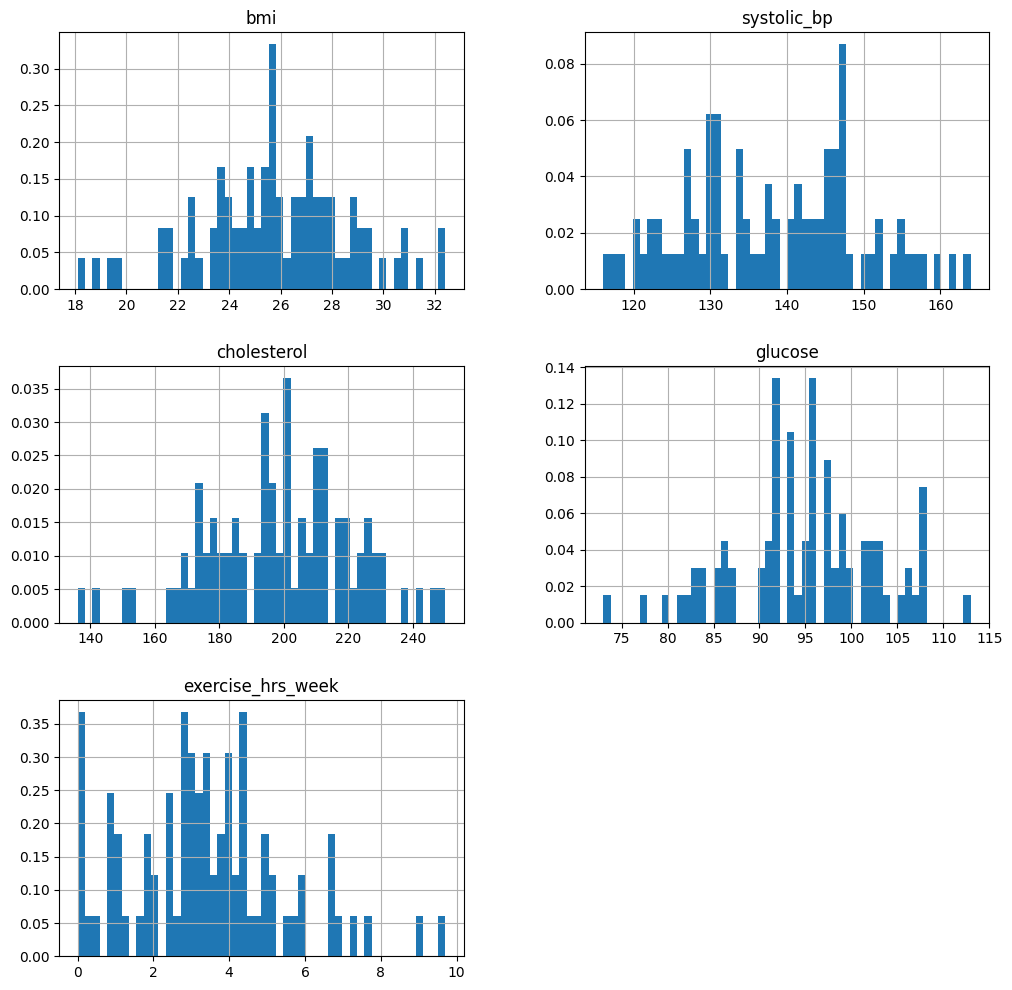

In [30]:
new_Data2.hist(bins=50, density=True, figsize=(12,12))
plt.show()

<Axes: >

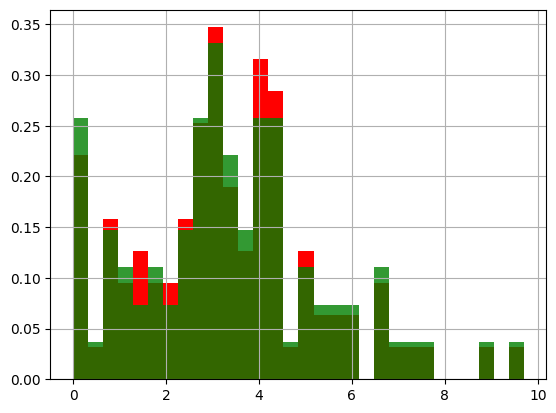

In [32]:
## overlap before CCA and after CCA histogram

fig = plt.figure()
ax = fig.add_subplot(111)

Data2['exercise_hrs_week'].hist(bins = 30, ax=ax, density = True, color ='red')

# alpha argument makes color transparent so that we can see the overlay of 2 distributions

new_Data2['exercise_hrs_week'].hist(bins = 30, ax=ax, density = True, color ='green', alpha=0.8)

<Axes: >

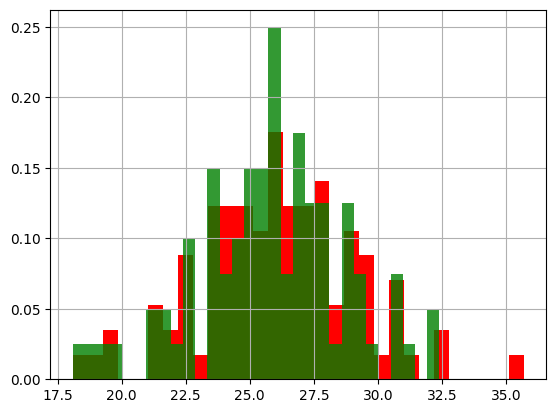

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data2['bmi'].hist(bins = 30, ax=ax, density = True, color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

new_Data2['bmi'].hist(bins = 30, ax=ax, density = True, color ='green', alpha=0.8)

<Axes: >

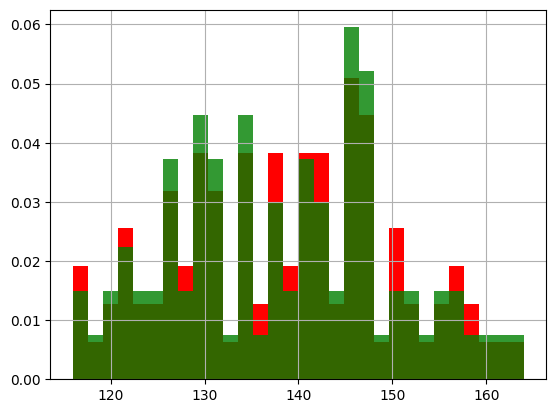

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data2['systolic_bp'].hist(bins = 30, ax=ax, density = True, color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

new_Data2['systolic_bp'].hist(bins = 30, ax=ax, density = True, color ='green', alpha=0.8)

<Axes: ylabel='Density'>

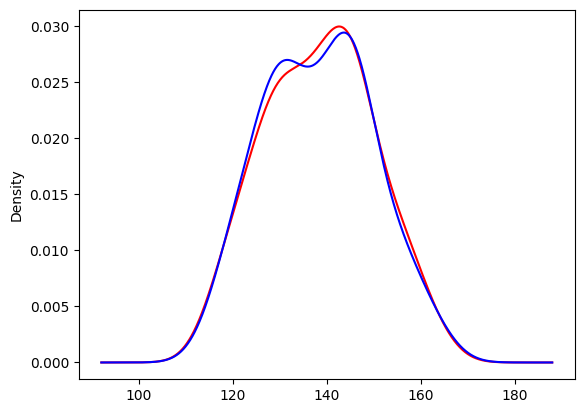

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data2['systolic_bp'].plot.density(color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

new_Data2['systolic_bp'].plot.density(color ='blue')

<Axes: >

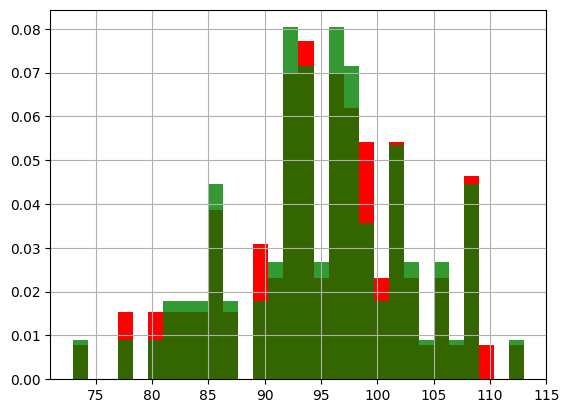

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data2['glucose'].hist(bins = 30, ax=ax, density = True, color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

new_Data2['glucose'].hist(bins = 30, ax=ax, density = True, color ='green', alpha=0.8)

<Axes: ylabel='Density'>

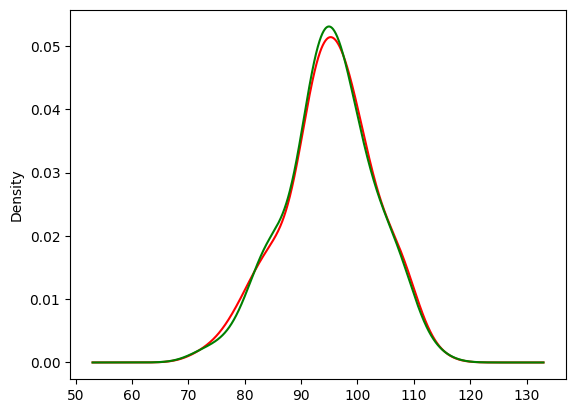

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data2['glucose'].plot.density(color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

new_Data2['glucose'].plot.density(color ='green')

In [43]:
Data2['smoker'].value_counts()


smoker
No     73
Yes    24
Name: count, dtype: int64

In [46]:
temp_data = pd.concat([Data2['smoker'].value_counts() / len(Data2),  ## percentage of missing data per category in original data
                     new_Data2['smoker'].value_counts() / len(new_Data2)], axis = 1)  ## ## percentage of missing data per category after CCA

temp_data.columns = ['original', 'cca']
temp_data

,original,cca
smoker,,
No,0.73,0.738095
Yes,0.24,0.261905


C:\Users\lands\AppData\Local\Temp\ipykernel_11552\3392400799.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  temp_data.hist(bins = 10, ax=ax, density = True, color ='red')
C:\Users\lands\AppData\Local\Temp\ipykernel_11552\3392400799.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  temp_data.hist(bins = 10, ax=ax, density = True, color ='green', alpha=0.8)


array([[<Axes: title={'center': 'original'}>,
        <Axes: title={'center': 'cca'}>]], dtype=object)

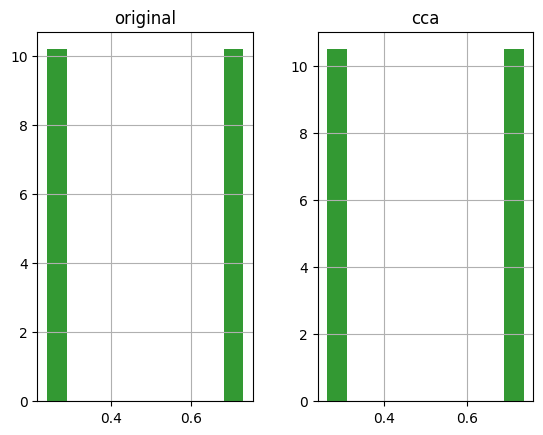

In [47]:
##  for categorical cols


fig = plt.figure()
ax = fig.add_subplot(111)

temp_data.hist(bins = 10, ax=ax, density = True, color ='red')

# alpha argument makes color tranparent, so we can see the overlayof 2 distributions

temp_data.hist(bins = 10, ax=ax, density = True, color ='green', alpha=0.8)

## filling the missing values

In [ ]:
## univariate  1. mean filling
               #2. Arbitrary value
               #3. End of distribution

##  use mean --- when normal distribution
##  use median --- when skewed distribution

##  disadvantage --- 1. changes the distribution, 2. creates outliers, 3. changes in corelation with other variables

## use them when <5% and missing completely at random

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
Data_1 = pd.read_csv('missing_values_study_100.csv')
Data_1.head()

,patient_id,age,sex,bmi,systolic_bp,cholesterol,glucose,exercise_hrs_week,smoker
0,1,26,F,26.4,120.0,183.0,91.0,2.9,No
1,2,26,F,22.5,128.0,NaN,78.0,1.5,No
2,3,39,M,24.8,135.0,209.0,82.0,4.1,No
3,4,46,F,29.3,147.0,212.0,93.0,4.4,No
4,5,54,F,18.1,132.0,177.0,96.0,4.3,Yes


In [6]:
Data_1.isnull().mean()

patient_id           0.00
age                  0.00
sex                  0.00
bmi                  0.03
systolic_bp          0.02
cholesterol          0.04
glucose              0.03
exercise_hrs_week    0.02
smoker               0.03
dtype: float64

In [7]:
X= Data_1.drop(columns=['sex', 'smoker', 'exercise_hrs_week', 'patient_id'])
X

,age,bmi,systolic_bp,cholesterol,glucose
0,26,26.4,120.0,183.0,91.0
1,26,22.5,128.0,NaN,78.0
2,39,24.8,135.0,209.0,82.0
3,46,29.3,147.0,212.0,93.0
4,54,18.1,132.0,177.0,96.0
...,...,...,...,...,...
95,65,26.9,158.0,174.0,93.0
96,35,24.1,141.0,173.0,106.0
97,41,23.6,124.0,231.0,84.0
98,51,30.9,148.0,194.0,94.0


In [8]:
Y= Data_1['exercise_hrs_week']
Y

0     2.9
1     1.5
2     4.1
3     4.4
4     4.3
     ... 
95    3.4
96    4.0
97    4.4
98    2.4
99    6.7
Name: exercise_hrs_week, Length: 100, dtype: float64

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=2)
X_train

,age,bmi,systolic_bp,cholesterol,glucose
65,38,25.8,126.0,193.0,96.0
1,26,22.5,128.0,NaN,78.0
18,41,22.2,130.0,227.0,86.0
48,48,19.4,142.0,211.0,85.0
36,42,26.1,141.0,178.0,102.0
...,...,...,...,...,...
43,39,25.8,139.0,228.0,84.0
22,40,28.6,122.0,198.0,97.0
72,25,30.8,117.0,219.0,103.0
15,35,24.1,116.0,175.0,89.0


In [13]:
X_train.shape

(70, 5)

In [11]:
X_test.shape

(30, 5)

In [14]:
X_train.isnull().mean()

age            0.000000
bmi            0.028571
systolic_bp    0.028571
cholesterol    0.042857
glucose        0.014286
dtype: float64

In [15]:
mean_age = X_train['age'].mean()
median_age = X_train['age'].median()

mean_bmi = X_train['bmi'].mean()
median_bmi = X_train['bmi'].median()

mean_systolic_bp = X_train['systolic_bp'].mean()
median_systolic_bp = X_train['systolic_bp'].median()

mean_cholesterol = X_train['cholesterol'].mean()
median_cholesterol = X_train['cholesterol'].median()

mean_glucose = X_train['glucose'].mean()
median_glucose = X_train['glucose'].median()

In [16]:
X_train['age_mean'] = X_train['age'].fillna(mean_age)
X_train['age_median'] = X_train['age'].fillna(median_age)

X_train['bmi_mean'] = X_train['bmi'].fillna(mean_bmi)
X_train['bmi_median'] = X_train['bmi'].fillna(median_bmi)

X_train['systolic_bp_mean'] = X_train['systolic_bp'].fillna(mean_systolic_bp)
X_train['systolic_bp_median'] = X_train['systolic_bp'].fillna(mean_systolic_bp)

X_train['cholesterol_mean'] = X_train['cholesterol'].fillna(mean_cholesterol)
X_train['cholesterol_median'] = X_train['cholesterol'].fillna(mean_cholesterol)

X_train['glucose_mean'] = X_train['glucose'].fillna(mean_glucose)
X_train['glucose_median'] = X_train['glucose'].fillna(mean_glucose)

In [18]:
X_train.sample(2)

,age,bmi,systolic_bp,cholesterol,glucose,age_mean,age_median,bmi_mean,bmi_median,systolic_bp_mean,systolic_bp_median,cholesterol_mean,cholesterol_median,glucose_mean,glucose_median
22,40,28.6,122.0,198.0,97.0,40,40,28.6,28.6,122.0,122.0,198.0,198.0,97.0,97.0
97,41,23.6,124.0,231.0,84.0,41,41,23.6,23.6,124.0,124.0,231.0,231.0,84.0,84.0


In [19]:
print('original age variance', X_train['age'].var())
print('mean imputed age variance', X_train['age_mean'].var())
print('median imputed age variance', X_train['age_median'].var())

print('original bmi variance', X_train['bmi'].var())
print('mean imputed bmi variance', X_train['bmi_mean'].var())
print('median imputed bmi variance', X_train['bmi_median'].var())

print('original systolic_bp variance', X_train['systolic_bp'].var())
print('mean imputed systolic_bp variance', X_train['systolic_bp_mean'].var())
print('median imputed systolic_bp variance', X_train['systolic_bp_median'].var())


print('original cholesterol variance', X_train['cholesterol'].var())
print('mean imputed cholesterol variance', X_train['cholesterol_mean'].var())
print('median imputed cholesterol variance', X_train['cholesterol_median'].var())

print('original glucose variance', X_train['glucose'].var())
print('mean imputed glucose variance', X_train['glucose_mean'].var())
print('median imputed glucose variance', X_train['glucose_median'].var())

original age variance 174.63022774327126
mean imputed age variance 174.63022774327126
median imputed age variance 174.63022774327126
original bmi variance 9.190190956979807
mean imputed bmi variance 8.92380861040068
median imputed bmi variance 8.923910973084887
original systolic_bp variance 115.49604916593503
mean imputed systolic_bp variance 112.14833759590793
median imputed systolic_bp variance 112.14833759590793
original cholesterol variance 488.96607869742195
mean imputed cholesterol variance 467.7066839714471
median imputed cholesterol variance 467.7066839714471
original glucose variance 61.89641943734015
mean imputed glucose variance 60.99936988027725
median imputed glucose variance 60.99936988027725


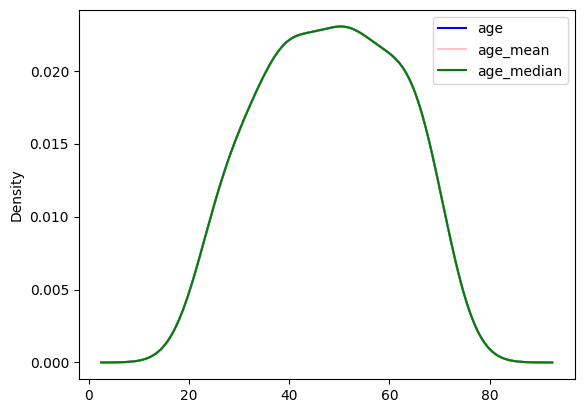

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['age'].plot(kind='kde', ax=ax, color='blue')
X_train['age_mean'].plot(kind='kde', ax=ax, color='pink')
X_train['age_median'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


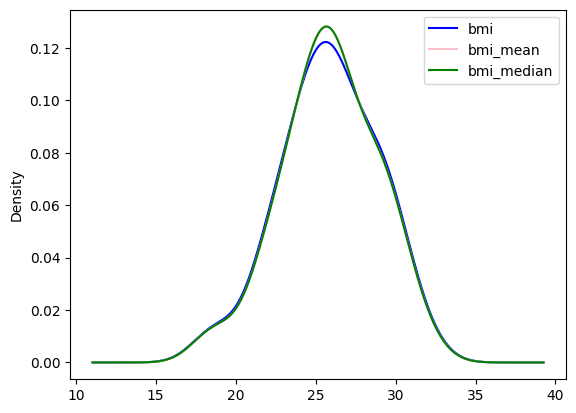

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['bmi'].plot(kind='kde', ax=ax, color='blue')
X_train['bmi_mean'].plot(kind='kde', ax=ax, color='pink')
X_train['bmi_median'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

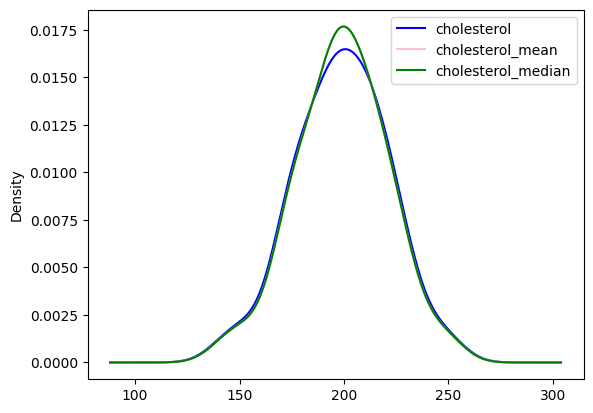

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['cholesterol'].plot(kind='kde', ax=ax, color='blue')
X_train['cholesterol_mean'].plot(kind='kde', ax=ax, color='pink')
X_train['cholesterol_median'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

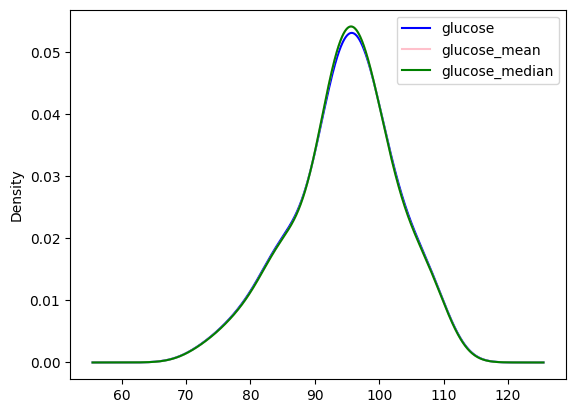

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['glucose'].plot(kind='kde', ax=ax, color='blue')
X_train['glucose_mean'].plot(kind='kde', ax=ax, color='pink')
X_train['glucose_median'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [27]:
X_train.cov()

,age,bmi,systolic_bp,cholesterol,glucose,age_mean,age_median,bmi_mean,bmi_median,systolic_bp_mean,systolic_bp_median,cholesterol_mean,cholesterol_median,glucose_mean,glucose_median
age,174.630228,4.488960,97.531168,88.583446,47.557545,174.630228,174.630228,4.358845,4.363064,94.704177,94.704177,84.731992,84.731992,46.868305,46.868305
bmi,4.488960,9.190191,3.281142,15.405769,8.115513,4.488960,4.488960,9.190191,9.190191,3.160529,3.160529,14.709772,14.709772,7.995072,7.995072
systolic_bp,97.531168,3.281142,115.496049,45.144056,33.263682,97.531168,97.531168,3.160529,3.174451,115.496049,115.496049,43.796601,43.796601,32.763942,32.763942
cholesterol,88.583446,15.405769,45.144056,488.966079,32.053147,88.583446,88.583446,14.932647,14.939846,44.460186,44.460186,488.966079,488.966079,31.560321,31.560321
glucose,47.557545,8.115513,33.263682,32.053147,61.896419,47.557545,47.557545,7.877497,7.876726,32.282120,32.282120,30.632076,30.632076,61.896419,61.896419
age_mean,174.630228,4.488960,97.531168,88.583446,47.557545,174.630228,174.630228,4.358845,4.363064,94.704177,94.704177,84.731992,84.731992,46.868305,46.868305
age_median,174.630228,4.488960,97.531168,88.583446,47.557545,174.630228,174.630228,4.358845,4.363064,94.704177,94.704177,84.731992,84.731992,46.868305,46.868305
bmi_mean,4.358845,9.190191,3.160529,14.932647,7.877497,4.358845,4.358845,8.923809,8.923809,3.068920,3.068920,14.283401,14.283401,7.763331,7.763331
bmi_median,4.363064,9.190191,3.174451,14.939846,7.876726,4.363064,4.363064,8.923809,8.923911,3.082438,3.082438,14.290288,14.290288,7.762571,7.762571
systolic_bp_mean,94.704177,3.160529,115.496049,44.460186,32.282120,94.704177,94.704177,3.068920,3.082438,112.148338,112.148338,42.527134,42.527134,31.814263,31.814263


In [31]:
X_train.corr()

,age,bmi,systolic_bp,cholesterol,glucose,age_mean,age_median,bmi_mean,bmi_median,systolic_bp_mean,systolic_bp_median,cholesterol_mean,cholesterol_median,glucose_mean,glucose_median
age,1.000000,0.114136,0.691070,0.314454,0.458418,1.000000,1.000000,0.110417,0.110523,0.676726,0.676726,0.296484,0.296484,0.454106,0.454106
bmi,0.114136,1.000000,0.101262,0.230200,0.338236,0.114136,0.114136,1.000000,1.000000,0.098732,0.098732,0.223457,0.223457,0.334754,0.334754
systolic_bp,0.691070,0.101262,1.000000,0.191951,0.388295,0.691070,0.691070,0.098784,0.099221,1.000000,1.000000,0.185688,0.185688,0.388216,0.388216
cholesterol,0.314454,0.230200,0.191951,1.000000,0.185896,0.314454,0.314454,0.227665,0.227776,0.191951,0.191951,1.000000,1.000000,0.185805,0.185805
glucose,0.458418,0.338236,0.388295,0.185896,1.000000,0.458418,0.458418,0.336233,0.336201,0.384686,0.384686,0.178772,0.178772,1.000000,1.000000
age_mean,1.000000,0.114136,0.691070,0.314454,0.458418,1.000000,1.000000,0.110417,0.110523,0.676726,0.676726,0.296484,0.296484,0.454106,0.454106
age_median,1.000000,0.114136,0.691070,0.314454,0.458418,1.000000,1.000000,0.110417,0.110523,0.676726,0.676726,0.296484,0.296484,0.454106,0.454106
bmi_mean,0.110417,1.000000,0.098784,0.227665,0.336233,0.110417,0.110417,1.000000,0.999994,0.097009,0.097009,0.221090,0.221090,0.332744,0.332744
bmi_median,0.110523,1.000000,0.099221,0.227776,0.336201,0.110523,0.110523,0.999994,1.000000,0.097436,0.097436,0.221196,0.221196,0.332710,0.332710
systolic_bp_mean,0.676726,0.098732,1.000000,0.191951,0.384686,0.676726,0.676726,0.097009,0.097436,1.000000,1.000000,0.185688,0.185688,0.384647,0.384647


<Axes: >

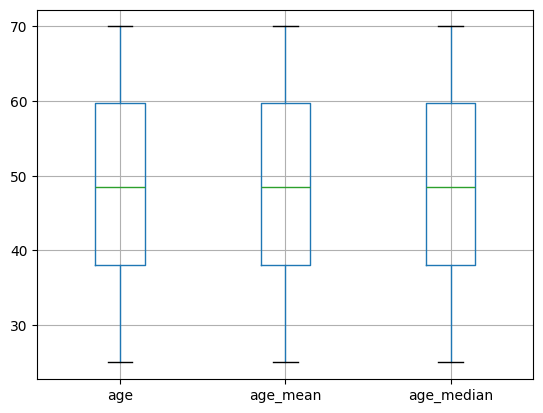

In [28]:
X_train[['age', 'age_mean', 'age_median']].boxplot()

<Axes: >

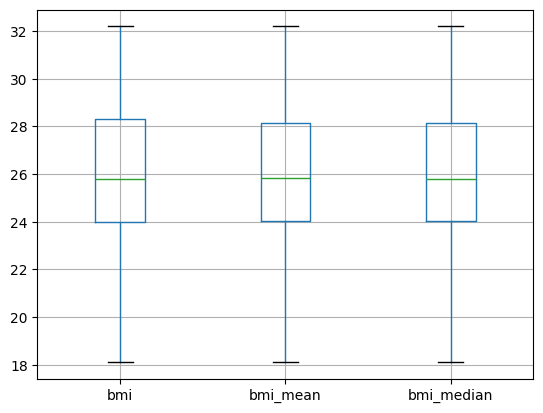

In [29]:
X_train[['bmi', 'bmi_mean', 'bmi_median']].boxplot()

<Axes: >

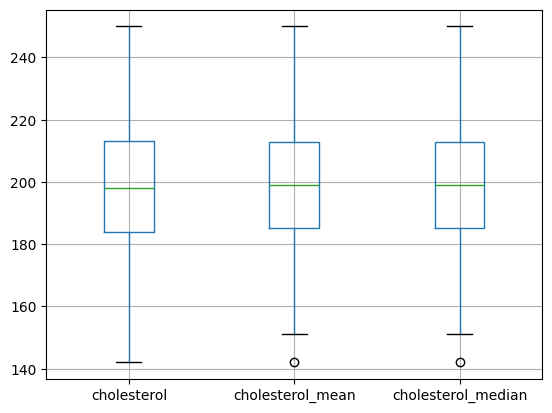

In [30]:
X_train[['cholesterol', 'cholesterol_mean', 'cholesterol_median']].boxplot()

In [32]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X, Y, test_size = 0.3, random_state=2)
X_train1

,age,bmi,systolic_bp,cholesterol,glucose
65,38,25.8,126.0,193.0,96.0
1,26,22.5,128.0,NaN,78.0
18,41,22.2,130.0,227.0,86.0
48,48,19.4,142.0,211.0,85.0
36,42,26.1,141.0,178.0,102.0
...,...,...,...,...,...
43,39,25.8,139.0,228.0,84.0
22,40,28.6,122.0,198.0,97.0
72,25,30.8,117.0,219.0,103.0
15,35,24.1,116.0,175.0,89.0


In [33]:
imputer_1 = SimpleImputer(strategy = 'mean')
imputer_2 = SimpleImputer(strategy = 'median')

In [38]:
trf1 = ColumnTransformer([('imputer1', imputer_1, ['age', 'bmi', 'cholesterol', 'glucose', 'systolic_bp']),
            ('imputer2', imputer_2, ['age', 'bmi', 'cholesterol', 'glucose', 'systolic_bp'])], remainder = 'passthrough')

In [39]:
trf1.fit(X_train1)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [40]:
trf1.named_transformers_

{'imputer1': SimpleImputer(), 'imputer2': SimpleImputer(strategy='median')}

In [44]:
trf1.named_transformers_['imputer1'].statistics_

array([ 47.91428571,  25.86029412, 198.94029851,  94.56521739,
       138.23529412])

In [46]:
X_train2 = trf1.transform(X_train1)
X_test2 = trf1.transform(X_test1)

In [47]:
X_train2

array([[ 38.        ,  25.8       , 193.        ,  96.        ,
        126.        ,  38.        ,  25.8       , 193.        ,
         96.        , 126.        ],
       [ 26.        ,  22.5       , 198.94029851,  78.        ,
        128.        ,  26.        ,  22.5       , 198.        ,
         78.        , 128.        ],
       [ 41.        ,  22.2       , 227.        ,  86.        ,
        130.        ,  41.        ,  22.2       , 227.        ,
         86.        , 130.        ],
       [ 48.        ,  19.4       , 211.        ,  85.        ,
        142.        ,  48.        ,  19.4       , 211.        ,
         85.        , 142.        ],
       [ 42.        ,  26.1       , 178.        , 102.        ,
        141.        ,  42.        ,  26.1       , 178.        ,
        102.        , 141.        ],
       [ 53.        ,  27.7       , 211.        , 108.        ,
        140.        ,  53.        ,  27.7       , 211.        ,
        108.        , 140.        ],
       [ 4

In [48]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X, Y, test_size = 0.3, random_state=2)
X_train2

,age,bmi,systolic_bp,cholesterol,glucose
65,38,25.8,126.0,193.0,96.0
1,26,22.5,128.0,NaN,78.0
18,41,22.2,130.0,227.0,86.0
48,48,19.4,142.0,211.0,85.0
36,42,26.1,141.0,178.0,102.0
...,...,...,...,...,...
43,39,25.8,139.0,228.0,84.0
22,40,28.6,122.0,198.0,97.0
72,25,30.8,117.0,219.0,103.0
15,35,24.1,116.0,175.0,89.0


### Arbitrary method -- used when data is missing in chunks

In [50]:
X_train2['age_99'] = X_train2['age'].fillna(99)
X_train2['age_minus1'] = X_train2['age'].fillna(-1)

X_train2['bmi_mean'] = X_train2['bmi'].fillna(99)
X_train2['bmi_median'] = X_train2['bmi'].fillna(-1)

X_train2['systolic_bp_mean'] = X_train2['systolic_bp'].fillna(99)
X_train2['systolic_bp_median'] = X_train2['systolic_bp'].fillna(-1)

X_train2['cholesterol_mean'] = X_train2['cholesterol'].fillna(99)
X_train2['cholesterol_median'] = X_train2['cholesterol'].fillna(-1)

X_train2['glucose_mean'] = X_train2['glucose'].fillna(99)
X_train2['glucose_median'] = X_train2['glucose'].fillna(-1)

In [51]:
print('original age variance', X_train2['age'].var())
print('99 imputed age variance', X_train2['age_mean'].var())
print('-1 imputed age variance', X_train2['age_median'].var())

print('original bmi variance', X_train2['bmi'].var())
print('mean imputed bmi variance', X_train2['bmi_mean'].var())
print('median imputed bmi variance', X_train2['bmi_median'].var())

print('original systolic_bp variance', X_train2['systolic_bp'].var())
print('mean imputed systolic_bp variance', X_train2['systolic_bp_mean'].var())
print('median imputed systolic_bp variance', X_train2['systolic_bp_median'].var())


print('original cholesterol variance', X_train2['cholesterol'].var())
print('mean imputed cholesterol variance', X_train2['cholesterol_mean'].var())
print('median imputed cholesterol variance', X_train2['cholesterol_median'].var())

print('original glucose variance', X_train2['glucose'].var())
print('mean imputed glucose variance', X_train2['glucose_mean'].var())
print('median imputed glucose variance', X_train2['glucose_median'].var())

original age variance 174.63022774327126
mean imputed age variance 174.63022774327126
median imputed age variance 174.63022774327126
original bmi variance 9.190190956979807
mean imputed bmi variance 159.54920289855076
median imputed bmi variance 29.238643892339542
original systolic_bp variance 115.49604916593503
mean imputed systolic_bp variance 155.49399585921324
median imputed systolic_bp variance 658.0198757763975
original cholesterol variance 488.96607869742195
mean imputed cholesterol variance 883.3590062111801
median imputed cholesterol variance 2131.3093167701863
original glucose variance 61.89641943734015
mean imputed glucose variance 61.28033126293995
median imputed glucose variance 191.46666666666664


### End of Distribution --- when data not missing at random

In [ ]:
##  by addin end values